In [2]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib as mpl
import numpy as np
import os    

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.style.use(['science', 'ieee'])
con = duckdb.connect(database = 'results.db', read_only = False)

output = widgets.Output()

plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.prop_cycle'] = mpl.cycler('linestyle', ['-', '--', ':', '-.']) + mpl.cycler('color', ['b', 'r', 'g', 'm'])

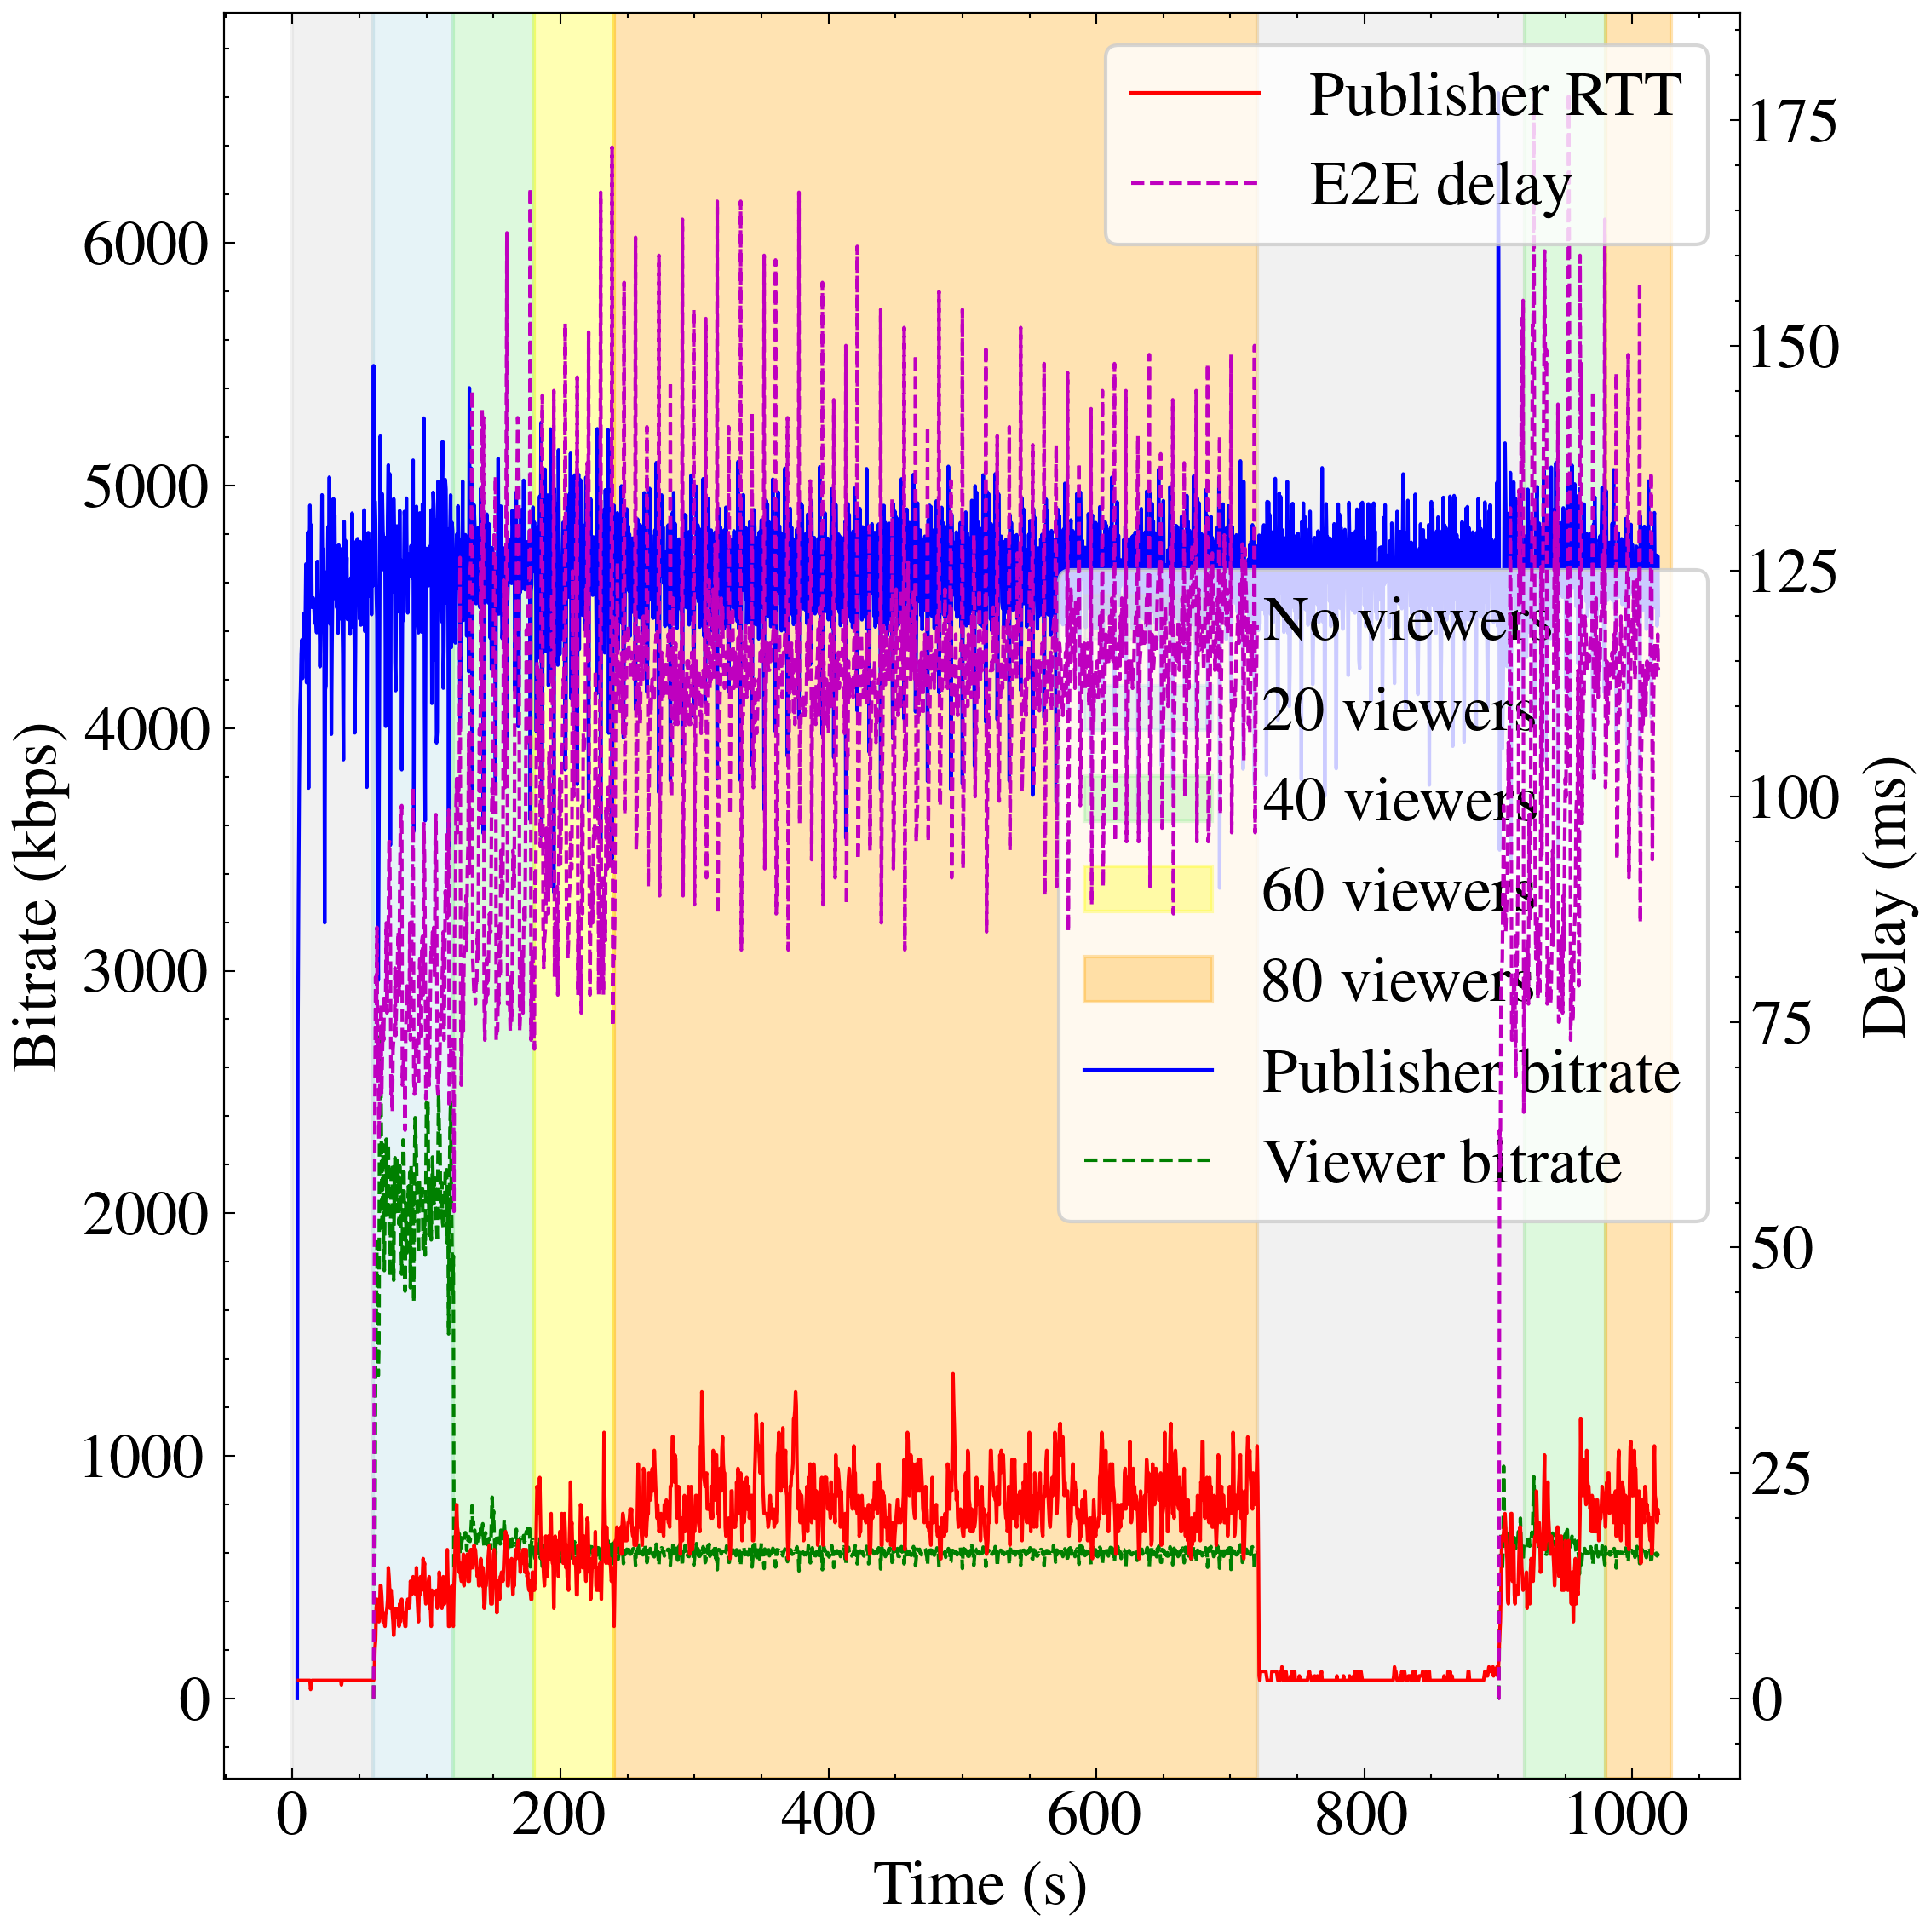

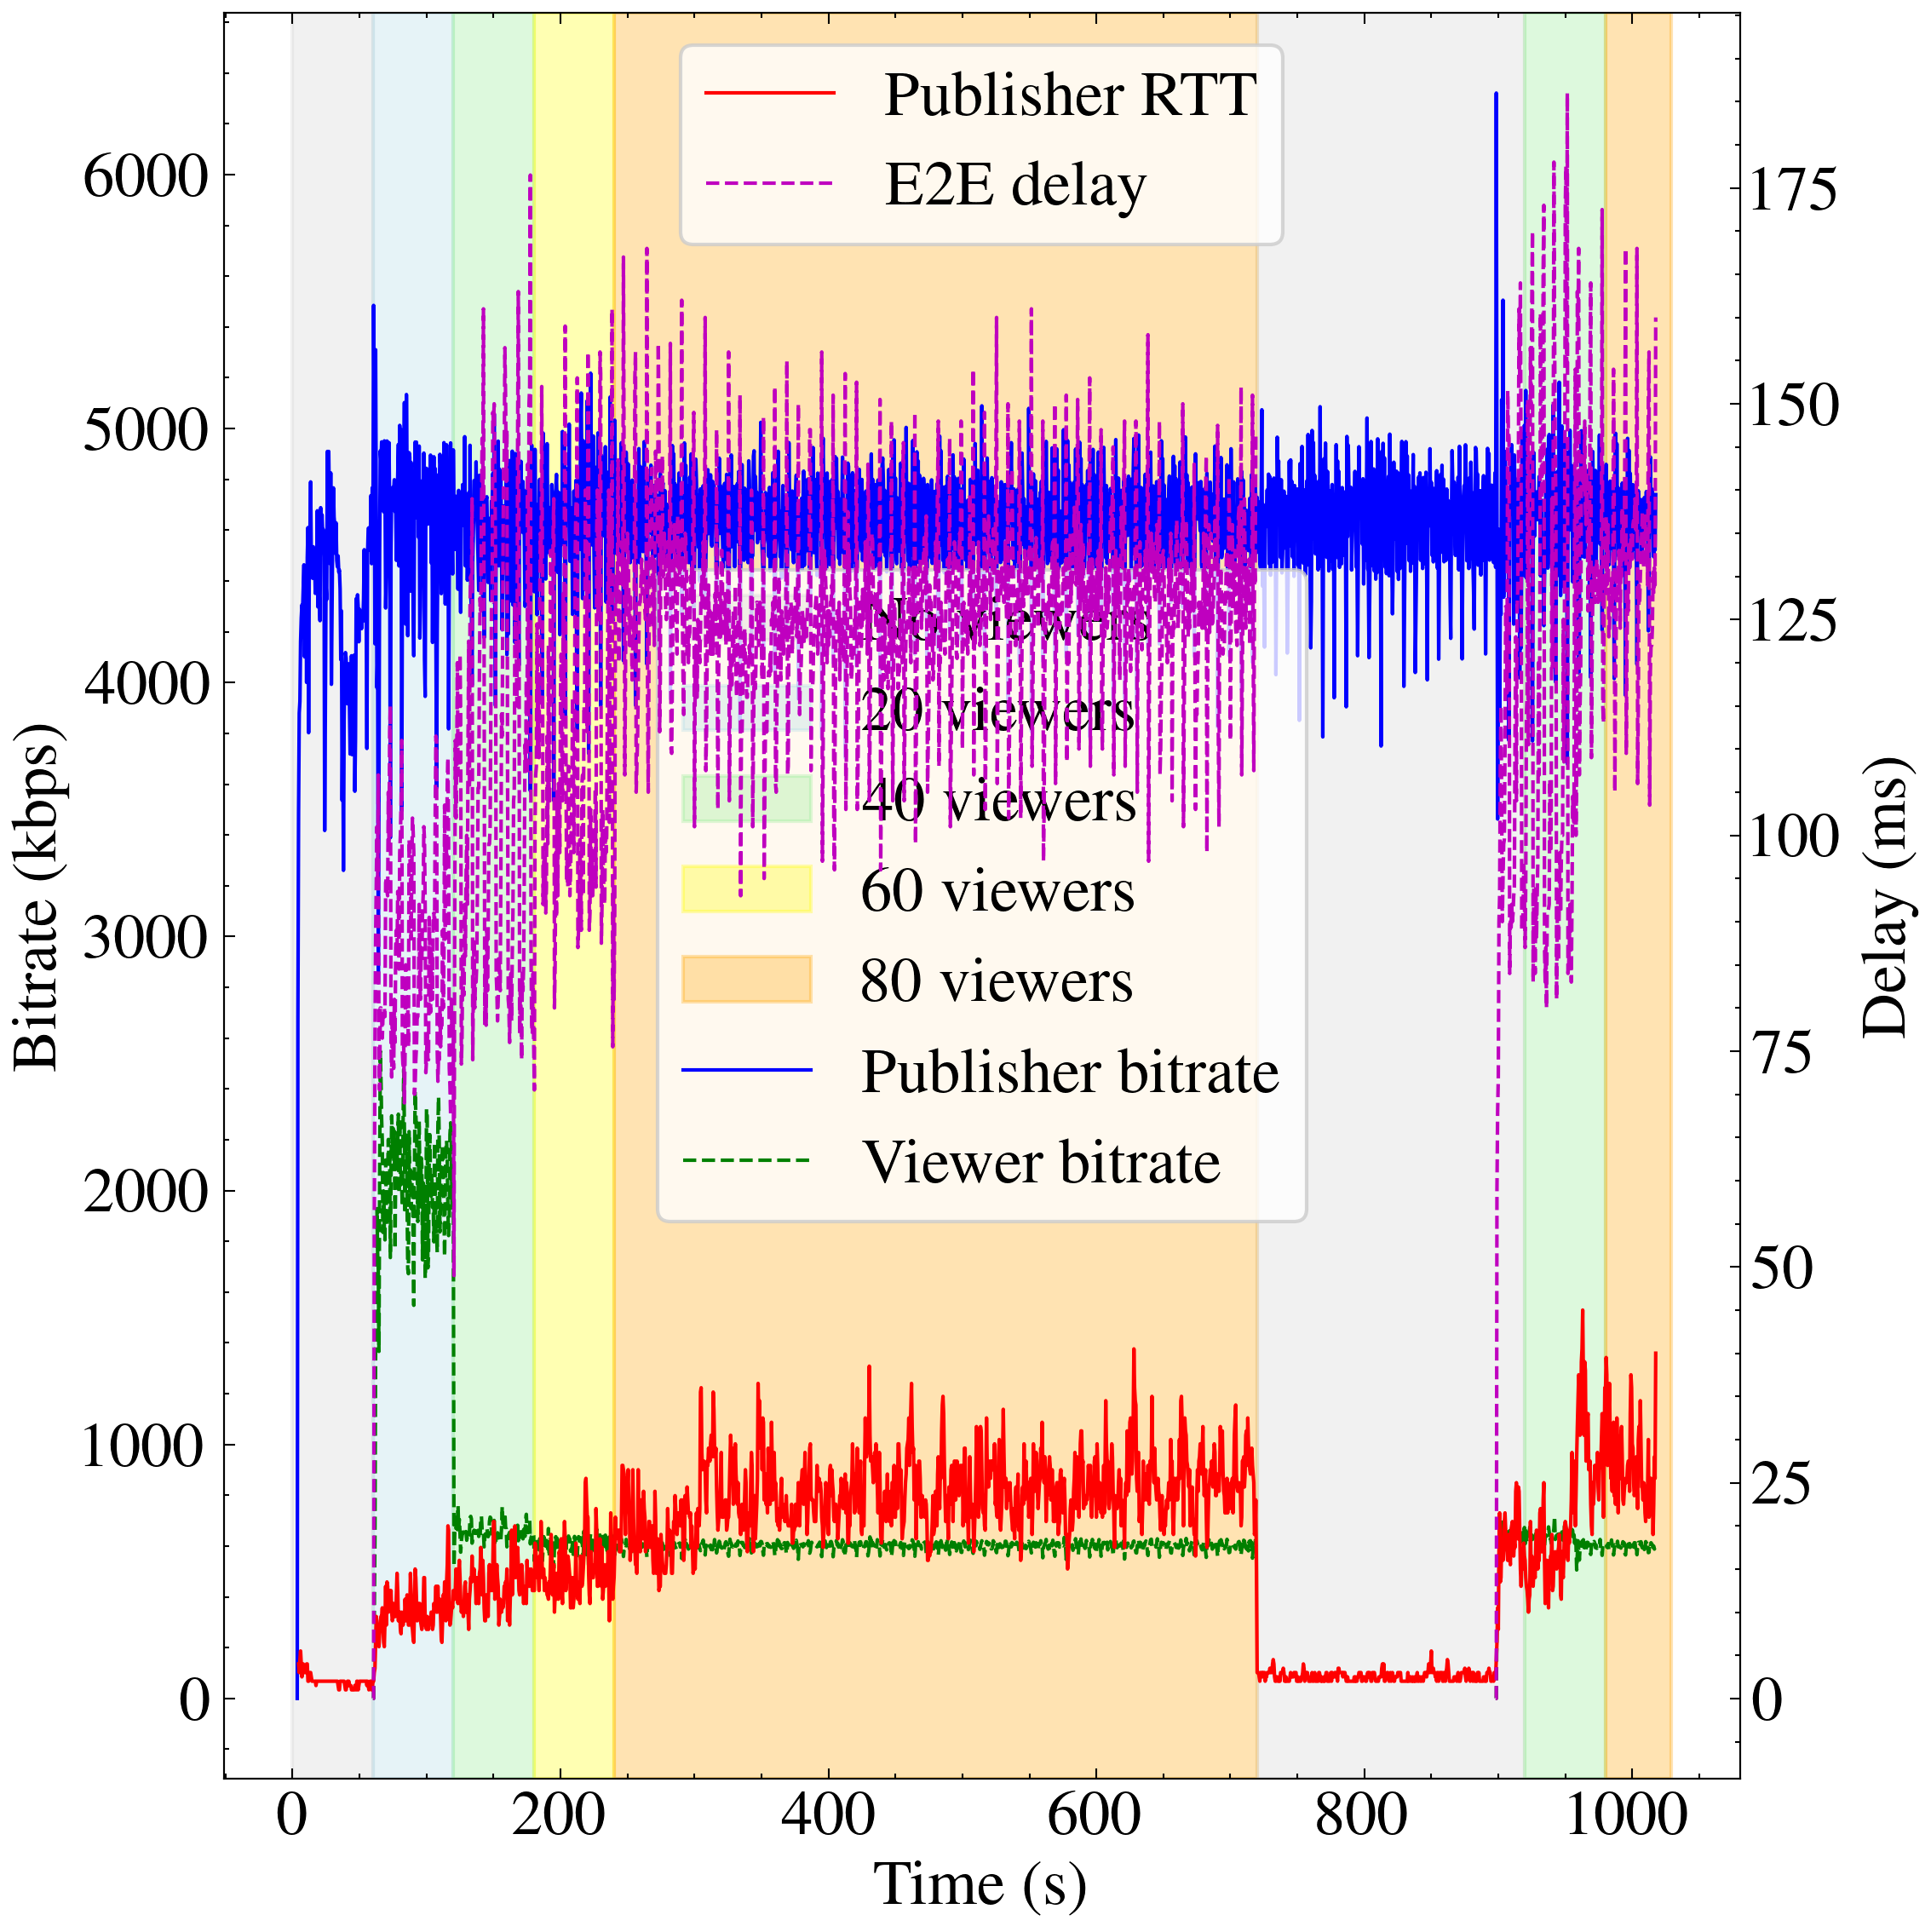

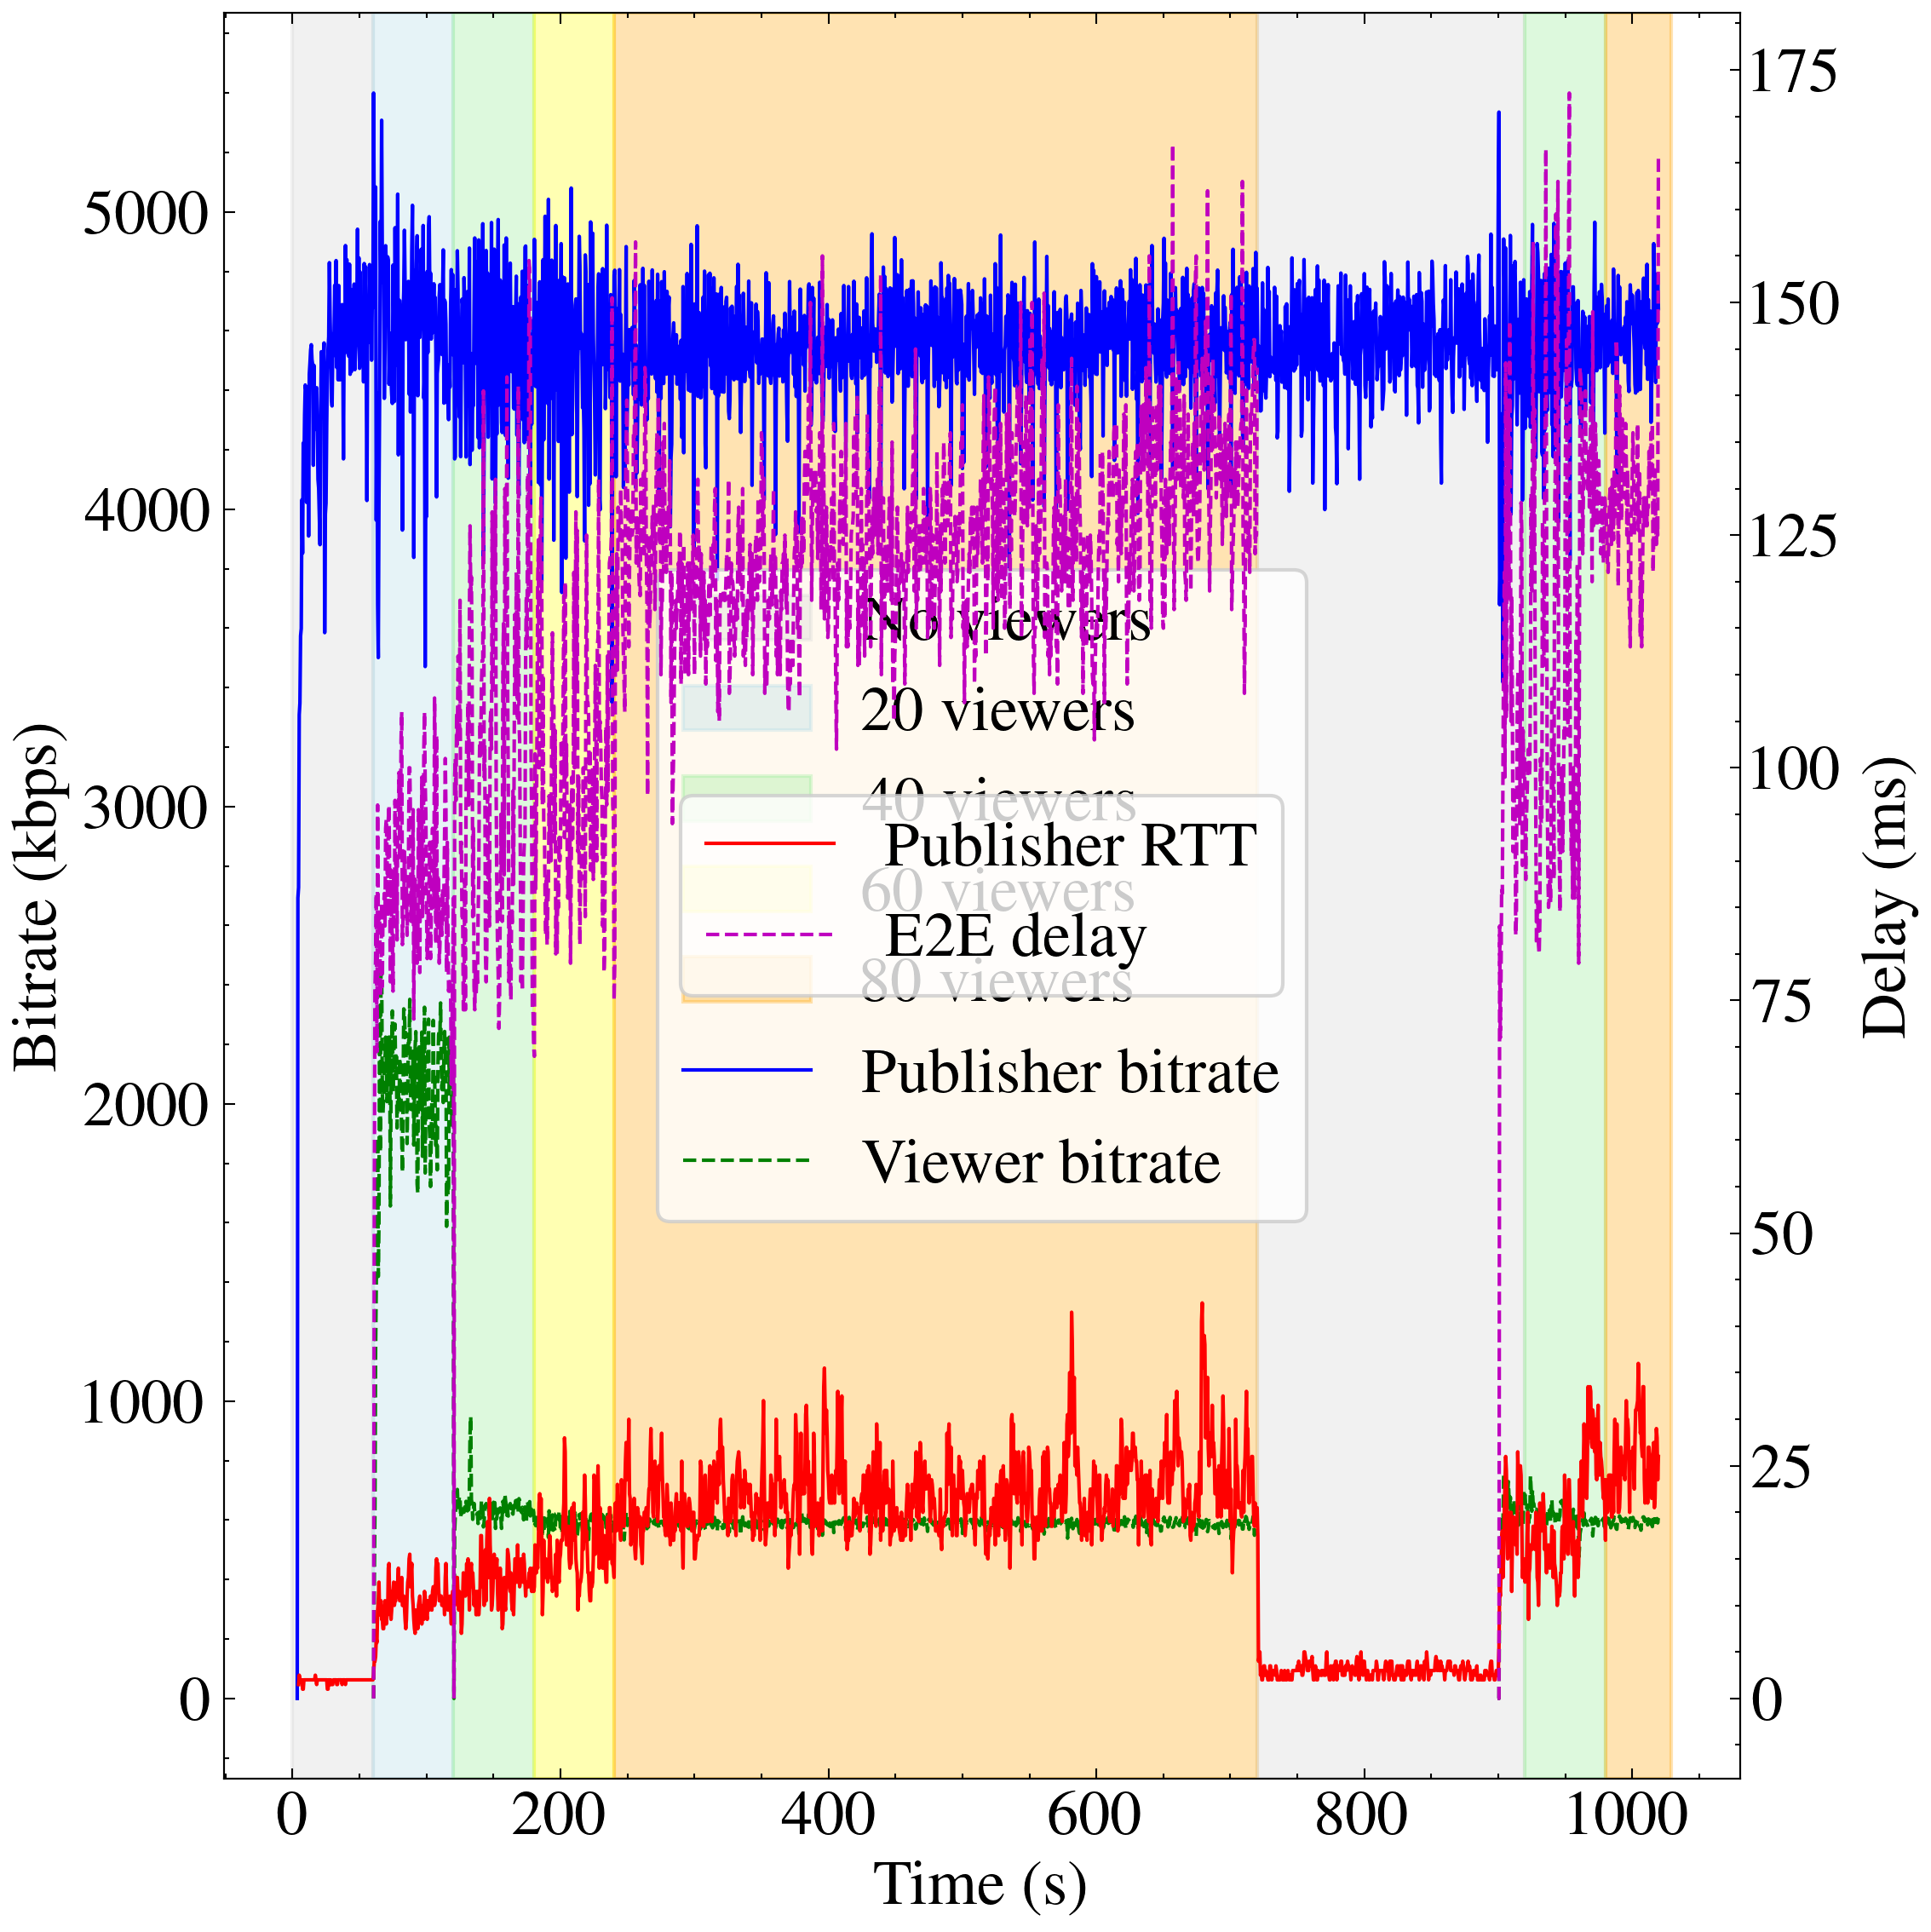

In [17]:
def go_annotate(ax):
    # Annotate the figure with background colors for different phases
    phases = [
        {"start": 0, "end": 60, "color": "lightgray", "label": "No viewers"},
        {"start": 60, "end": 120, "color": "lightblue", "label": "20 viewers"},
        {"start": 120, "end": 180, "color": "lightgreen", "label": "40 viewers"},
        {"start": 180, "end": 240, "color": "yellow", "label": "60 viewers"},
        {"start": 240, "end": 720, "color": "orange", "label": "80 viewers"},
        {"start": 720, "end": 920, "color": "lightgray", "label": None },
        {"start": 920, "end": 980, "color": "lightgreen", "label": None },
        {"start": 980, "end": None, "color": "orange", "label": None },
    ]

    for phase in phases:
        ax.axvspan(
            phase["start"],
            phase["end"] if phase["end"] is not None else ax.get_xlim()[1],
            color=phase["color"],
            alpha=0.3,
            label=phase["label"]
        )

def gen_figs_regul(name, exp):
    query = f"""
    SELECT TIME, MEDIAN("PUBLISHER BITRATE") AS bitrate, MEDIAN("PUBLISHER RTT") AS rtt
    FROM stats
    WHERE exp_name='{exp}'
    GROUP BY TIME
    ORDER BY TIME
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

    go_annotate(ax)
    
    bx = ax.twinx()
    
    ax.plot(df["TIME"]/1000, df["bitrate"], label="Publisher bitrate", color='b', linewidth=1)
    bx.plot(df["TIME"]/1000, df["rtt"], label="Publisher RTT", color='r', linewidth=1)
    
    query = f"""
    SELECT time, MEDIAN("bitrate") AS bitrate, MEDIAN("delay") as delay
    FROM viewers
    WHERE exp_name='{exp}'
    GROUP BY time
    ORDER BY time
    """
    df = con.execute(query).pl()
    
    ax.plot(df["time"]/1000, df["bitrate"], label="Viewer bitrate", color='g', linewidth=1)
    bx.plot(df["time"]/1000, df["delay"], label="E2E delay", color='m', linewidth=1)
    
    ax.set_xlabel('Time (s)', fontweight='bold')
    ax.set_ylabel('Bitrate (kbps)', fontweight='bold')
    bx.set_ylabel('Delay (ms)', fontweight='bold')    
    
    ax.legend(frameon=True)
    bx.legend(frameon=True)
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/{name}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

gen_figs_regul('regul_baseline','noregul-viewer-increase-double-longer-par20')
gen_figs_regul('regul_balloon','balloon-pid-viewer-increase-double-longer-par20')
gen_figs_regul('regul_cgroups','cgroups-regul-stddev-30-viewer-double-increase-par20')

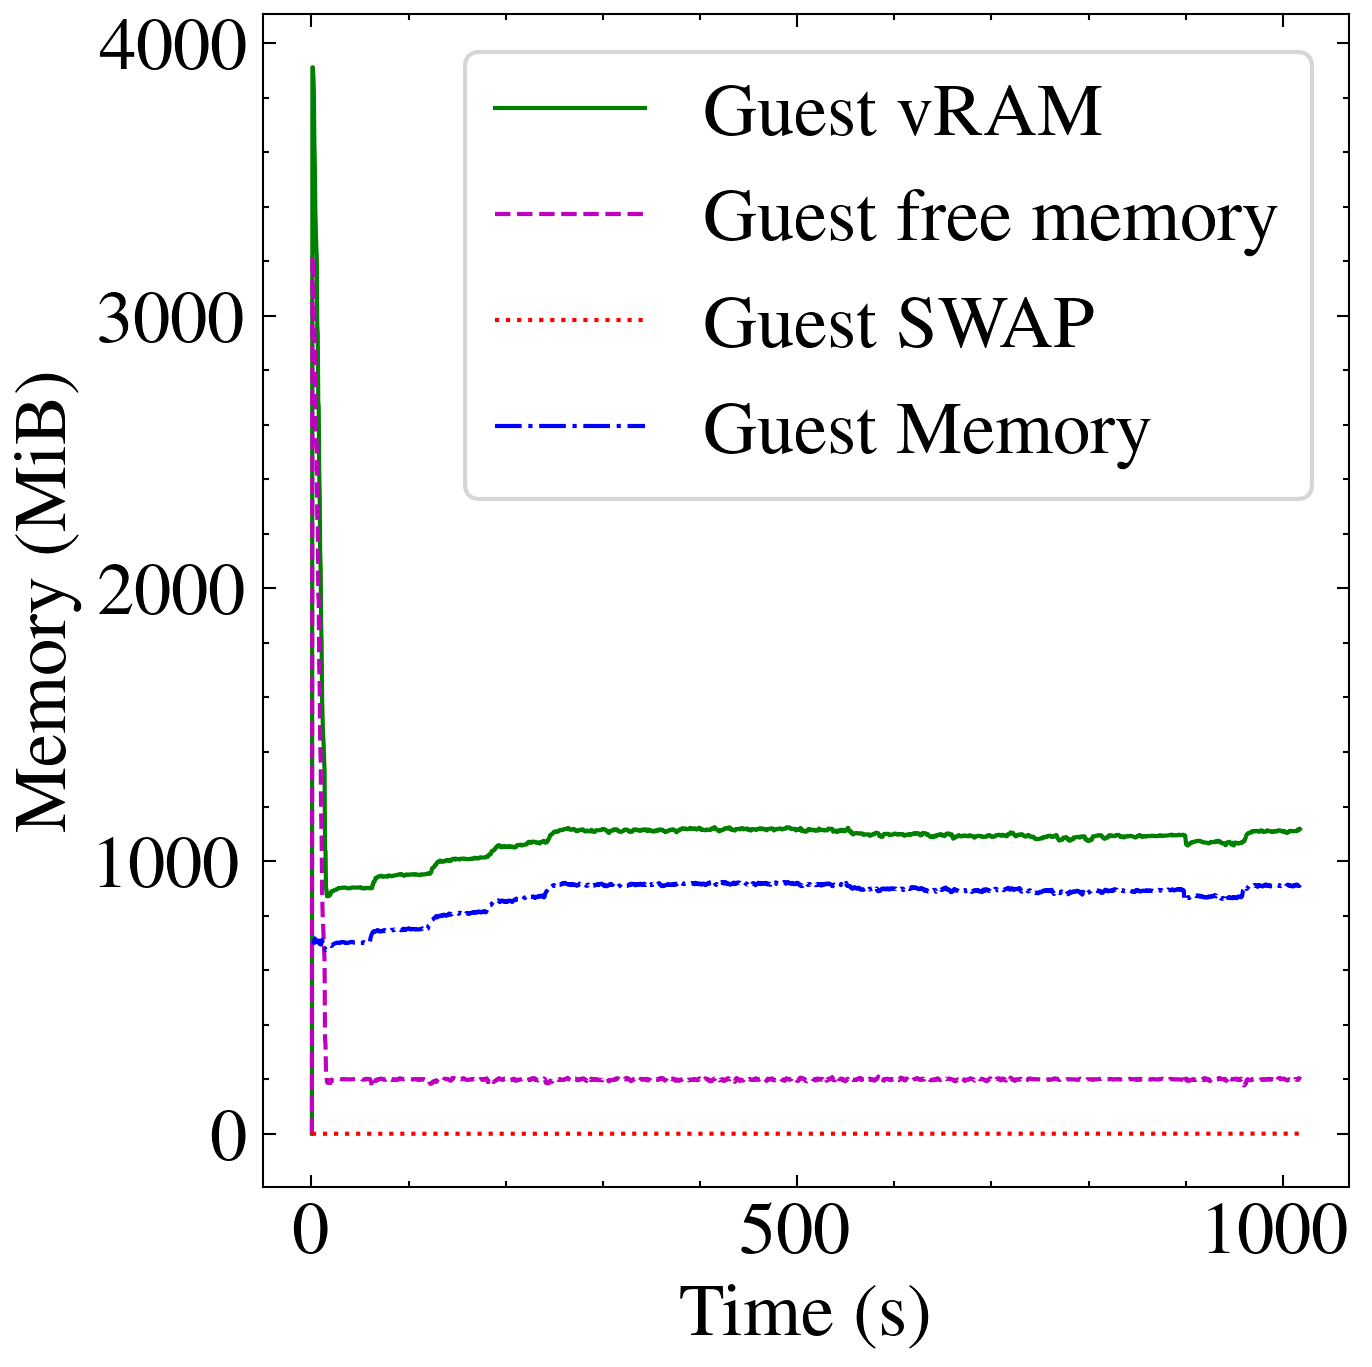

In [5]:
query = """
SELECT TIME, 
       MEDIAN("VIRSH AVAILABLE") AS "Guest vRAM",
       MEDIAN("VIRSH USABLE") AS "Guest free memory",
       MEDIAN("VIRSH SWAP OUT") AS "Guest SWAP",
       MEDIAN("VM MEMORY USAGE") AS "Guest Memory"
FROM stats
WHERE exp_name='balloon-pid-viewer-increase-double-longer-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["Guest vRAM"]/(1024), label="Guest vRAM", color='g', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest free memory"]/(1024), label="Guest free memory", color='m', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest SWAP"]/(1024), label="Guest SWAP", color='r', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest Memory"], label="Guest Memory", color='b', linewidth=1)
    
ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/ballon_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()

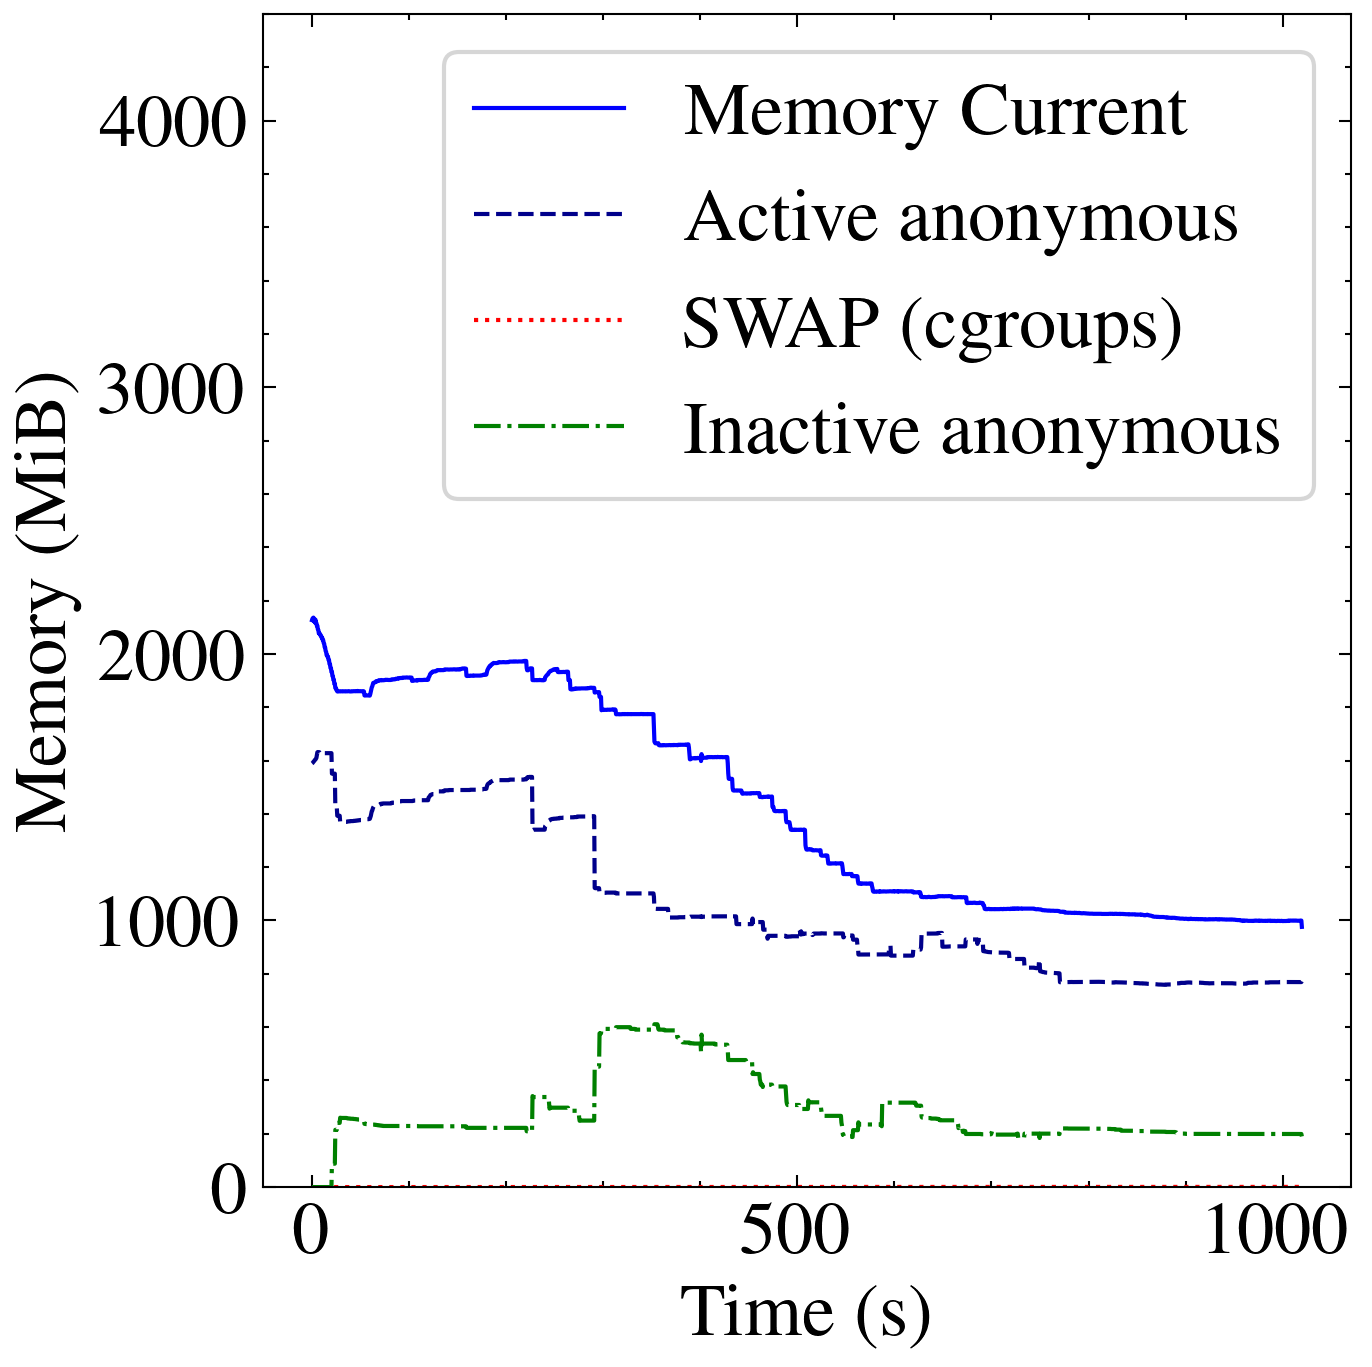

In [6]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY CURRENT") AS "ram",
       MEDIAN("ACTIVE ANON") AS "active",
       MEDIAN("SWAP CURRENT") AS "swap",
       MEDIAN("INACTIVE ANON") AS "inactive"
FROM cgroup_stats
WHERE exp_name='cgroups-regul-stddev-30-viewer-double-increase-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["ram"], label="Memory Current", color='b')
ax.plot(df["TIME"]/1000, df["active"]/(1024*1024), label="Active anonymous", color='darkblue')
ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')
ax.plot(df["TIME"]/1000, df["inactive"]/(1024*1024), label="Inactive anonymous", color='g')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,4400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/cgroup_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()

shape: (717, 6)
┌────────┬─────────┬──────────┬──────┬────────────┬──────────────────────┐
│ TIME   ┆ hostram ┆ guestram ┆ swap ┆ available  ┆ count("MEMORY USED") │
│ ---    ┆ ---     ┆ ---      ┆ ---  ┆ ---        ┆ ---                  │
│ i64    ┆ f64     ┆ f64      ┆ f64  ┆ f64        ┆ i64                  │
╞════════╪═════════╪══════════╪══════╪════════════╪══════════════════════╡
│ 500    ┆ 1742.0  ┆ null     ┆ 0.0  ┆ 0.0        ┆ 11                   │
│ 1000   ┆ 1744.0  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 1500   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2000   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2500   ┆ 1744.0  ┆ 693.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ …      ┆ …       ┆ …        ┆ …    ┆ …          ┆ …                    │
│ 356500 ┆ 2396.0  ┆ 726.0    ┆ 0.0  ┆ 4.004688e6 ┆ 1                    │
│ 357000 ┆ 2396.0  ┆ 726.0    ┆ 0.0  ┆ 4.004688e6 ┆ 1                    │
│ 357500 

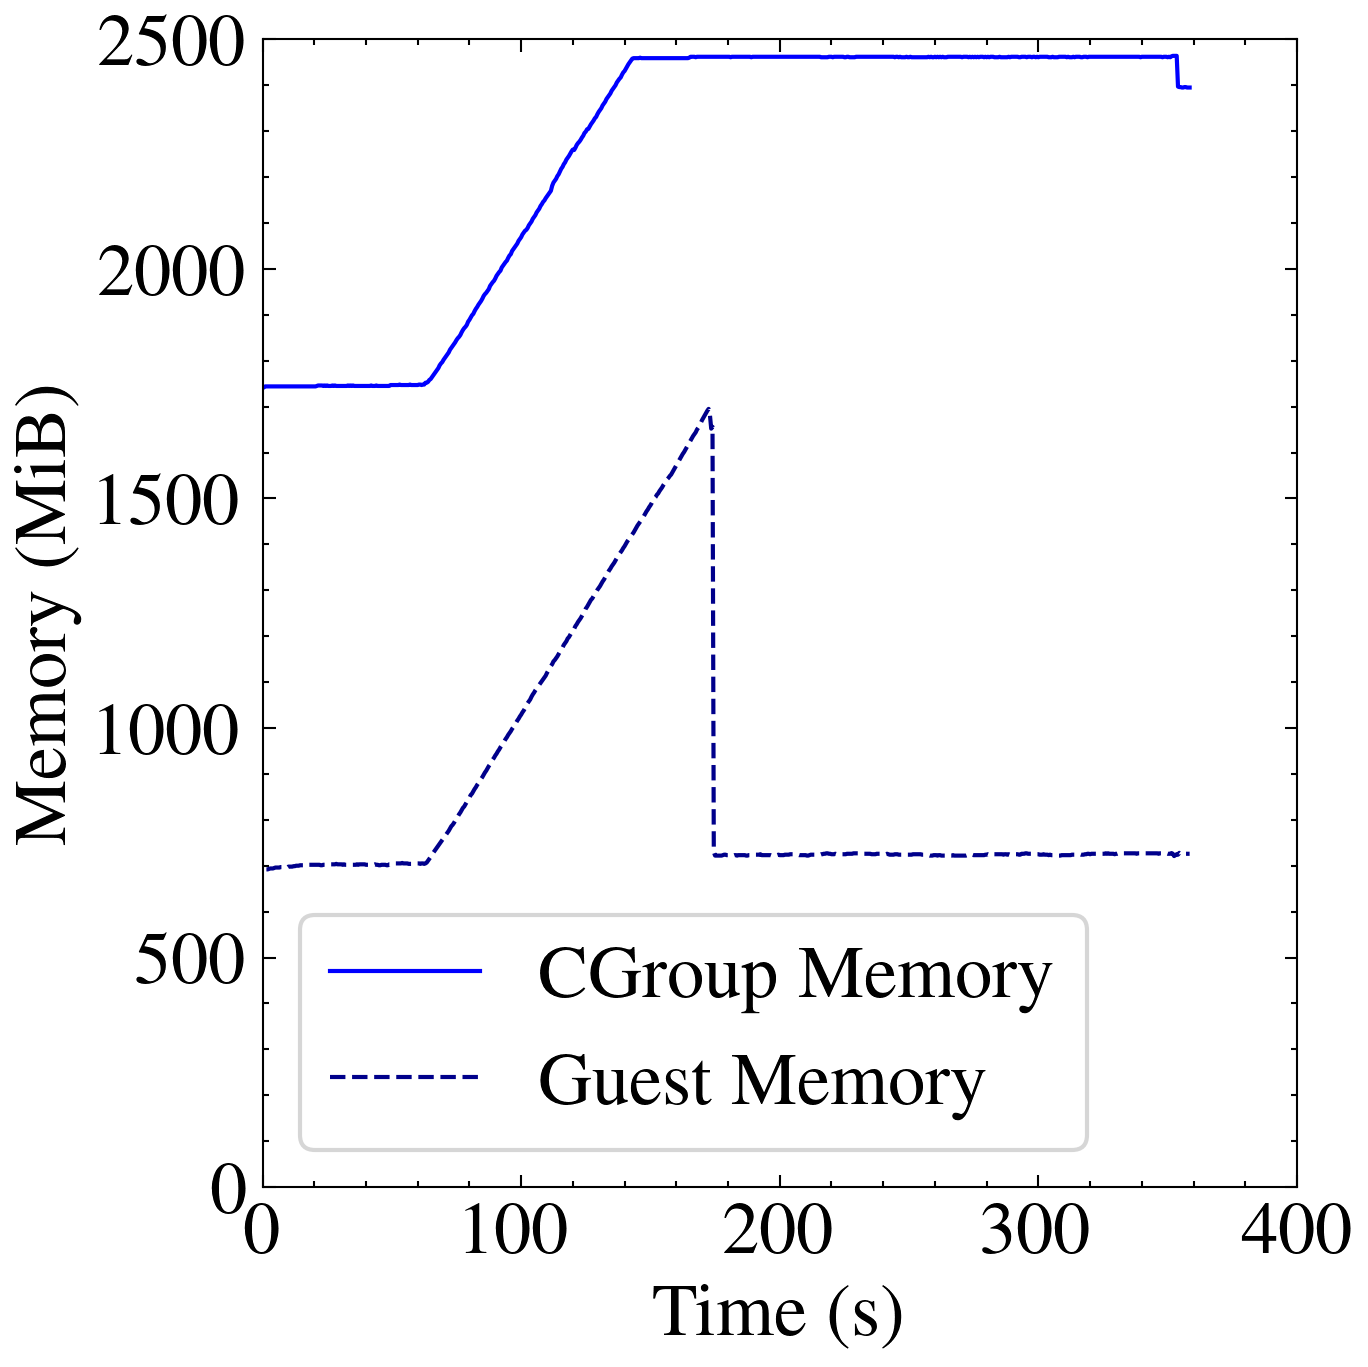

In [7]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='baseline-pid-mongodb-latest'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()
print(df)

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
# ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')
# ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Inactive anonymous", color='g')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(0,400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

shape: (880, 6)
┌────────┬─────────┬──────────┬──────┬────────────┬──────────────────────┐
│ TIME   ┆ hostram ┆ guestram ┆ swap ┆ available  ┆ count("MEMORY USED") │
│ ---    ┆ ---     ┆ ---      ┆ ---  ┆ ---        ┆ ---                  │
│ i64    ┆ f64     ┆ f64      ┆ f64  ┆ f64        ┆ i64                  │
╞════════╪═════════╪══════════╪══════╪════════════╪══════════════════════╡
│ 500    ┆ 1682.0  ┆ null     ┆ 0.0  ┆ 0.0        ┆ 10                   │
│ 1000   ┆ 1682.5  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 1500   ┆ 1682.0  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 2000   ┆ 1682.5  ┆ 694.5    ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 2500   ┆ 1682.0  ┆ 695.0    ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ …      ┆ …       ┆ …        ┆ …    ┆ …          ┆ …                    │
│ 438000 ┆ 1235.0  ┆ 739.0    ┆ 0.0  ┆ 961284.0   ┆ 7                    │
│ 438500 ┆ 1235.0  ┆ 739.0    ┆ 0.0  ┆ 961284.0   ┆ 7                    │
│ 439000 

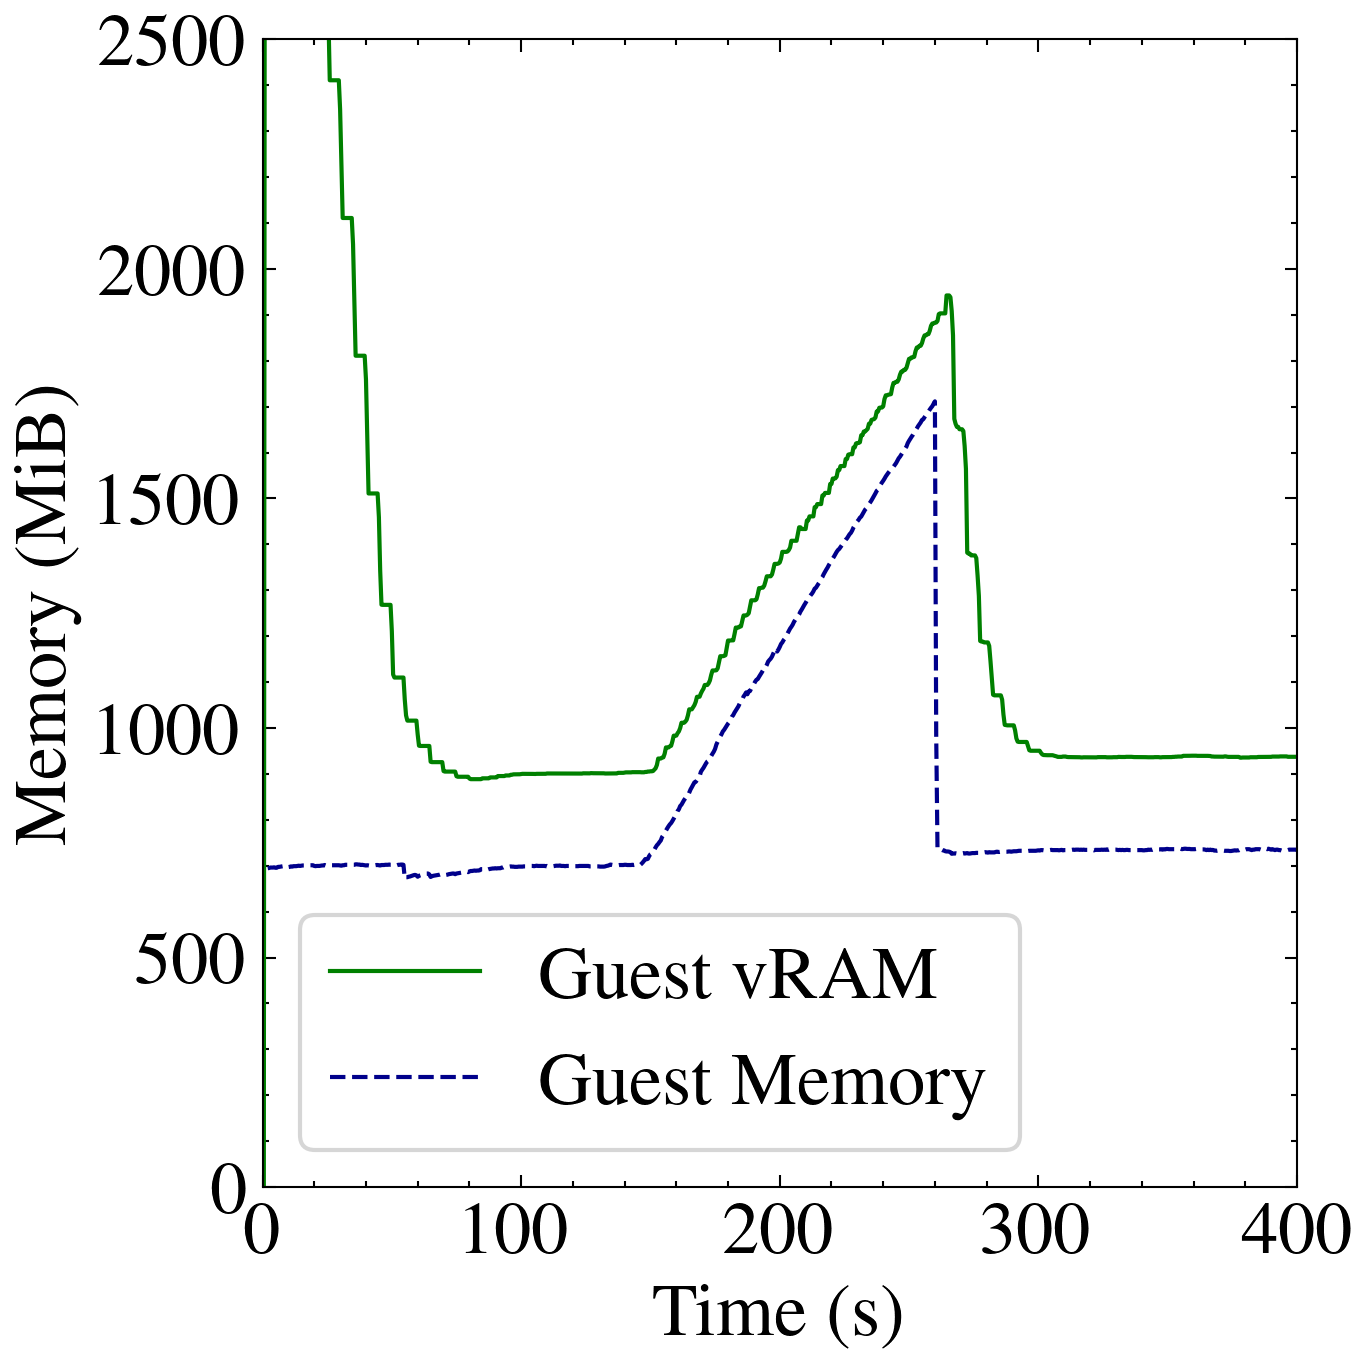

In [8]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='balloon-pid-mongodb-latest-300'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()
print(df)

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Guest vRAM", color='g')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
# ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(0,400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

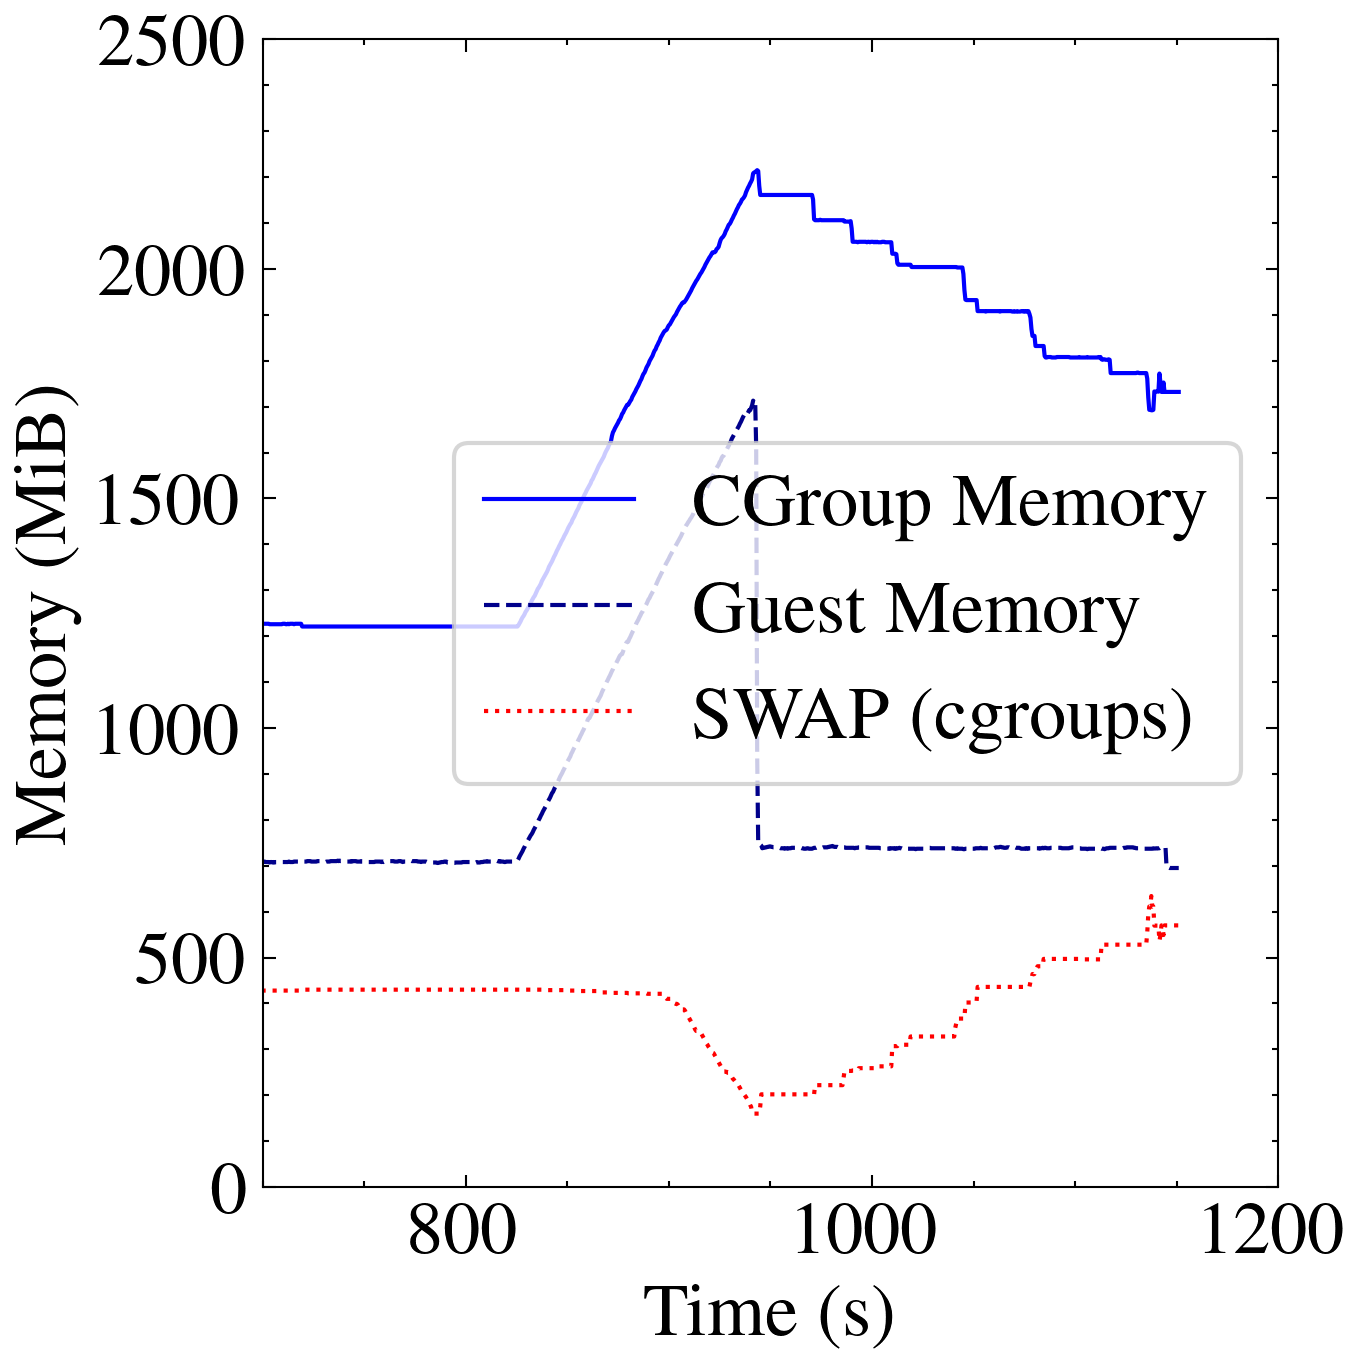

In [9]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='cgroups-pid-mongodb-latest'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
# ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Guest vRAM", color='g')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
ax.plot(df["TIME"]/1000, df["swap"], label="SWAP (cgroups)", color='r')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(700,1200)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [56]:
query = """
"""
df = con.execute(query).pl()
print(df)


shape: (0, 11)
┌──────────┬──────┬───────────┬──────┬───┬───────┬─────┬────────────┬─────┐
│ exp_name ┆ date ┆ client_id ┆ time ┆ … ┆ delay ┆ fps ┆ resolution ┆ rid │
│ ---      ┆ ---  ┆ ---       ┆ ---  ┆   ┆ ---   ┆ --- ┆ ---        ┆ --- │
│ str      ┆ str  ┆ i32       ┆ i32  ┆   ┆ i32   ┆ i32 ┆ str        ┆ str │
╞══════════╪══════╪═══════════╪══════╪═══╪═══════╪═════╪════════════╪═════╡
└──────────┴──────┴───────────┴──────┴───┴───────┴─────┴────────────┴─────┘
